In [16]:
import numpy as np
import pandas as pd

df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**amount & time: to be scaled**

Outlier Sensitivity: 
- Standard Scaler is highly sensitive to outliers, which can skew the mean and standard deviation, distorting the scaled values.
- RobustScaler ignores outliers, focusing on the central 50% of the data.

In [17]:
def do_scaling (df, s):
    if s == "Robust":
        from sklearn.preprocessing import RobustScaler
        df['Amount'] = RobustScaler().fit_transform(df['Amount'].values.reshape(-1, 1)) 
        df['Time'] = RobustScaler().fit_transform(df['Time'].values.reshape(-1, 1))
    else:
        from sklearn.preprocessing import StandardScaler
        df['Amount'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1, 1)) 
        df['Time'] = StandardScaler().fit_transform(df['Time'].values.reshape(-1, 1))    

In [18]:
do_scaling(df, "Robust")
# do_scaling(df, "Standard")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0


In [19]:
y = df['Class']
X = df.drop(columns=['Class'])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)

**parameters tuning** was done on another file on [colab](https://colab.research.google.com/drive/1yruDM_dZ3-tp-3rbwgACiXUrL2c3zB9t#scrollTo=ys5MJ-wzlz5J)

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'scale_pos_weight': 5}

In [22]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "XGBoost": XGBClassifier(
        n_jobs = 1,
        eval_metric = 'logloss',
        learning_rate = 0.1,
        max_depth = 3,
        n_estimators = 500,
        scale_pos_weight = 5,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 100,
        random_state = 42,
        n_jobs = 1,
    )
}


**TRYING MODELS BEFORE ANY SAMPLINGs!**

also, tuning parameters before Sampling, maybe I will try after Sampling as well (if these ones go bad)

In [23]:
from collections import Counter
print(Counter(y_train))

Counter({0: 227451, 1: 394})


^^^

without sampling, 0/1 imbalance 

In [35]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    average_precision_score, confusion_matrix
)
    
def show_scores(y_pred, y_pred_proba, y_test):
    # y_pred = to_discrete(y_pred_proba, 0.1)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}")
    print(f"PR-AUC:   {average_precision_score(y_test, y_pred_proba[:, 1]):.4f}")
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
    print("-" * 30)

In [10]:
for name, model_obj in models.items():
    print(f"Model Name: {name}")
    
    model_obj.fit(X_train, y_train)
    y_pred = model_obj.predict(X_test)
    y_pred_proba = model_obj.predict_proba(X_test)
    
    show_scores(y_pred, y_pred_proba, y_test)
    
    results_df = pd.DataFrame(X_test, columns=X.columns)
    results_df['actual'] = y_test.values
    results_df['pred'] = y_pred
    results_df['proba'] = y_pred_proba[:, 1]

Model Name: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:03:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9995
F1 Score: 0.8586
ROC-AUC:  0.9775
PR-AUC:   0.8686
TP: 82 | TN: 56853 | FP: 11 | FN: 16
------------------------------
Model Name: Random Forest
Accuracy: 0.9996
F1 Score: 0.8743
ROC-AUC:  0.9630
PR-AUC:   0.8734
TP: 80 | TN: 56859 | FP: 5 | FN: 18
------------------------------


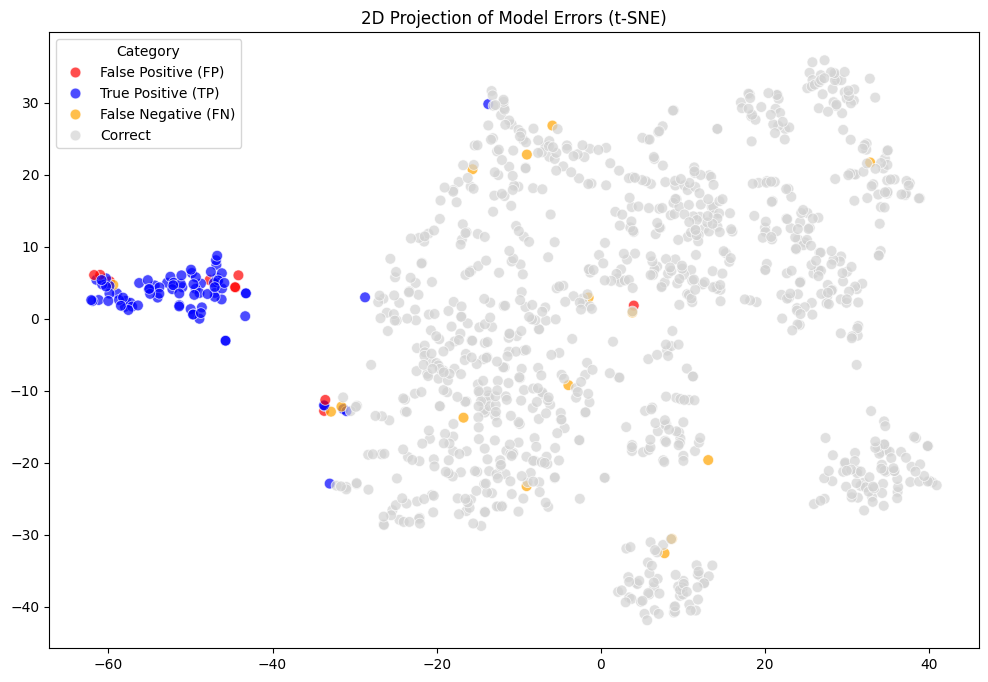

In [29]:
# from sklearn.metrics import precision_recall_curve

# # Get probabilities
# y_scores = model.predict_proba(X_test)[:, 1]
# precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# # Find the threshold that gives you the best F1 score
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# best_threshold = thresholds[np.argmax(f1_scores)]

# # print(f"Best Threshold for F1: {best_threshold}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Prepare the data: Let's look at the errors vs a sample of correct ones
results_df = pd.DataFrame(X_test, columns=X.columns)
results_df['actual'] = y_test.values
results_df['pred'] = y_pred

# Define categories
results_df['Category'] = 'Correct'
results_df.loc[(results_df['actual'] == 0) & (results_df['pred'] == 1), 'Category'] = 'False Positive (FP)'
results_df.loc[(results_df['actual'] == 1) & (results_df['pred'] == 0), 'Category'] = 'False Negative (FN)'
results_df.loc[(results_df['actual'] == 1) & (results_df['pred'] == 1), 'Category'] = 'True Positive (TP)'

# 2. Sample for visualization (t-SNE is slow on 50k+ rows)
# We keep ALL errors and TPs, but only a small portion of "Correct" normals
errors_tp = results_df[results_df['Category'] != 'Correct']
normals_sample = results_df[results_df['Category'] == 'Correct'].sample(1000, random_state=42)
viz_df = pd.concat([errors_tp, normals_sample])

# 3. Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_2d = tsne.fit_transform(viz_df.drop(['actual', 'pred', 'Category'], axis=1))

# 4. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=data_2d[:, 0], y=data_2d[:, 1],
    hue=viz_df['Category'],
    palette={'Correct': 'lightgrey', 'False Positive (FP)': 'red', 
             'False Negative (FN)': 'orange', 'True Positive (TP)': 'blue'},
    alpha=0.7,
    s=60
)
plt.title("2D Projection of Model Errors (t-SNE)")
plt.show()

**trying SMOTE here**

In [25]:
from imblearn.over_sampling import SMOTE

# Initialize sampler
smote = SMOTE(random_state=42)

# Fit and apply transform
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print(Counter(y_resampled))

Counter({0: 227451, 1: 227451})


In [26]:
print("HERE WE GO\n")
for name, model_obj in models.items():
    print(f"Model Name: {name}")
    
    model_obj.fit(X_resampled, y_resampled)
    y_pred = model_obj.predict(X_test)
    y_pred_proba = model_obj.predict_proba(X_test)
    
    show_scores(y_pred, y_pred_proba, y_test)
    

HERE WE GO

Model Name: XGBoost
Accuracy: 0.9950
F1 Score: 0.3733
ROC-AUC:  0.9795
PR-AUC:   0.8310
TP: 84 | TN: 56596 | FP: 268 | FN: 14
------------------------------
Model Name: Random Forest
Accuracy: 0.9995
F1 Score: 0.8497
ROC-AUC:  0.9733
PR-AUC:   0.8699
TP: 82 | TN: 56851 | FP: 13 | FN: 16
------------------------------


In [29]:
from collections import Counter
print(Counter(y_test))

Counter({0: 56864, 1: 98})


trying **Borderline SMOTE** here

In [31]:
from imblearn.over_sampling import BorderlineSMOTE

smote_borderline_1 = BorderlineSMOTE(
    sampling_strategy = 'auto',
    random_state = 0,
    k_neighbors = 5,
    m_neighbors = 10,
    kind = 'borderline-1',
    # n_jobs = -1
)

smote_borderline_2 = BorderlineSMOTE(
    sampling_strategy = 'auto',
    random_state = 0,
    k_neighbors = 5,
    m_neighbors = 10,
    kind = 'borderline-2',
    # n_jobs = -1
)

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote_borderline_2.fit_resample(X_train, y_train)

print(Counter(y_resampled))

Counter({0: 227451, 1: 227451})


In [34]:
print("HERE WE GO\n")
for name, model_obj in models.items():
    print(f"Model Name: {name}")
    
    model_obj.fit(X_resampled, y_resampled)
    y_pred = model_obj.predict(X_test)
    y_pred_proba = model_obj.predict_proba(X_test)
    
    show_scores(y_pred, y_pred_proba, y_test)

HERE WE GO

Model Name: XGBoost
Accuracy: 0.9993
F1 Score: 0.8057
ROC-AUC:  0.9737
PR-AUC:   0.8639
TP: 85 | TN: 56836 | FP: 28 | FN: 13
------------------------------
Model Name: Random Forest
Accuracy: 0.9995
F1 Score: 0.8492
ROC-AUC:  0.9573
PR-AUC:   0.8641
TP: 76 | TN: 56859 | FP: 5 | FN: 22
------------------------------


whyyy **SMOTE** & **Borderline SMOTE** are giving less F1 and overall anythign?????

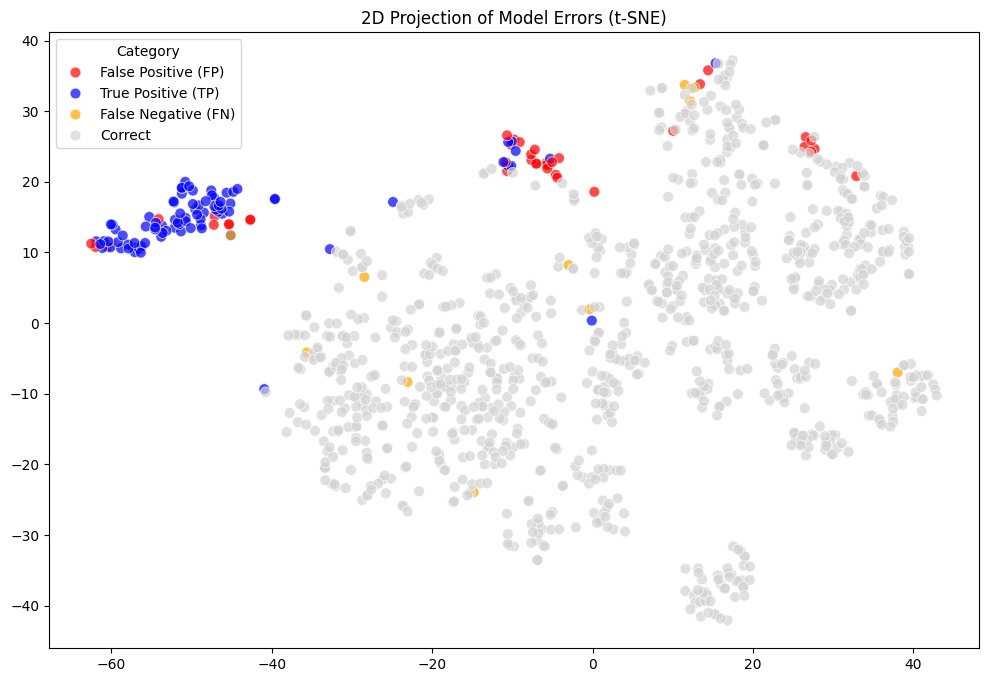

In [22]:
results_df = pd.DataFrame(X_test, columns=X.columns)
results_df['actual'] = y_test.values
results_df['pred'] = y_pred
results_df['proba'] = y_pred_proba[:, 1]

# from sklearn.metrics import precision_recall_curve

# # Get probabilities
# y_scores = model.predict_proba(X_test)[:, 1]
# precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# # Find the threshold that gives you the best F1 score
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# best_threshold = thresholds[np.argmax(f1_scores)]

# # print(f"Best Threshold for F1: {best_threshold}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 1. Prepare the data: Let's look at the errors vs a sample of correct ones
results_df = pd.DataFrame(X_test, columns=X.columns)
results_df['actual'] = y_test.values
results_df['pred'] = y_pred

# Define categories
results_df['Category'] = 'Correct'
results_df.loc[(results_df['actual'] == 0) & (results_df['pred'] == 1), 'Category'] = 'False Positive (FP)'
results_df.loc[(results_df['actual'] == 1) & (results_df['pred'] == 0), 'Category'] = 'False Negative (FN)'
results_df.loc[(results_df['actual'] == 1) & (results_df['pred'] == 1), 'Category'] = 'True Positive (TP)'

# 2. Sample for visualization (t-SNE is slow on 50k+ rows)
# We keep ALL errors and TPs, but only a small portion of "Correct" normals
errors_tp = results_df[results_df['Category'] != 'Correct']
normals_sample = results_df[results_df['Category'] == 'Correct'].sample(1000, random_state=42)
viz_df = pd.concat([errors_tp, normals_sample])

# 3. Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_2d = tsne.fit_transform(viz_df.drop(['actual', 'pred', 'Category'], axis=1))

# 4. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=data_2d[:, 0], y=data_2d[:, 1],
    hue=viz_df['Category'],
    palette={'Correct': 'lightgrey', 'False Positive (FP)': 'red', 
             'False Negative (FN)': 'orange', 'True Positive (TP)': 'blue'},
    alpha=0.7,
    s=60
)
plt.title("2D Projection of Model Errors (t-SNE)")
plt.show()

In [24]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)

In [26]:
print(Counter(y_resampled))

Counter({0: 394, 1: 394})


In [28]:
print("HERE WE GO\n")
for name, model_obj in models.items():
    print(f"Model Name: {name}")
    
    model_obj.fit(X_resampled, y_resampled)
    y_pred = model_obj.predict(X_test)
    y_pred_proba = model_obj.predict_proba(X_test)
    
    show_scores(y_pred, y_pred_proba, y_test)

HERE WE GO

Model Name: XGBoost
Accuracy: 0.9950
F1 Score: 0.3733
ROC-AUC:  0.9795
PR-AUC:   0.8310
TP: 84 | TN: 56596 | FP: 268 | FN: 14
------------------------------
Model Name: Random Forest
Accuracy: 0.9995
F1 Score: 0.8497
ROC-AUC:  0.9733
PR-AUC:   0.8699
TP: 82 | TN: 56851 | FP: 13 | FN: 16
------------------------------


**under sampling** - red flag??